# 02 EDA — Men's

Exploratory data analysis of men's basketball data to inform feature engineering and modeling decisions.

**Key questions:**
1. How predictive are seeds? What are upset rates by seed matchup?
2. Which Massey Ordinal systems best predict tournament outcomes?
3. Which team-season stats separate tournament winners from losers?
4. How have scoring and pace trends changed over time?
5. What features correlate most with tournament success?

**Inputs** (from S3 `01_data_joining/mens/`):
- `regular_season_games.parquet`
- `tourney_games.parquet`
- `team_season_stats.parquet`
- `tourney_seeds.parquet`
- `massey_ordinals_pre_tourney.parquet`
- `team_metadata.parquet`

**Outputs**: Plots saved to `02_eda/output/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

#### Functions

In [2]:
def read_parquet(filename):
    """Read parquet from S3 if available, otherwise fall back to local."""
    try:
        return pd.read_parquet(f"{INPUT_PREFIX}{filename}")
    except Exception:
        return pd.read_parquet(f"{LOCAL_INPUT}{filename}")

def save_plot(fig, name):
    """Save plot to local output directory."""
    fig.savefig(f"{LOCAL_OUTPUT}{name}.png", bbox_inches='tight', dpi=150)
    print(f"Saved: {LOCAL_OUTPUT}{name}.png")

#### Constants

In [3]:
BUCKET = "march-machine-learning-mania-2026"
GENDER = "mens"
STAGE = "02_eda"
INPUT_PREFIX = f"s3://{BUCKET}/01_data_joining/{GENDER}/"
OUTPUT_PREFIX = f"s3://{BUCKET}/{STAGE}/{GENDER}/"

LOCAL_INPUT = "../01_data_joining/output/"
LOCAL_OUTPUT = "output/"

#### Make output directory

In [4]:
os.makedirs(LOCAL_OUTPUT, exist_ok=True)

## 1. Load Data

In [5]:
reg_games = read_parquet("regular_season_games.parquet")
tourney_games = read_parquet("tourney_games.parquet")
team_stats = read_parquet("team_season_stats.parquet")
seeds = read_parquet("tourney_seeds.parquet")
massey = read_parquet("massey_ordinals_pre_tourney.parquet")
team_meta = read_parquet("team_metadata.parquet")

print(f"Regular season games: {reg_games.shape}")
print(f"Tournament games: {tourney_games.shape}")
print(f"Team-season stats: {team_stats.shape}")
print(f"Seeds: {seeds.shape}")
print(f"Massey ordinals: {massey.shape}")
print(f"Team metadata: {team_meta.shape}")

Regular season games: (198079, 34)
Tournament games: (2585, 34)
Team-season stats: (13753, 72)
Seeds: (2626, 6)
Massey ordinals: (13764, 195)
Team metadata: (13753, 7)


## 2. Seed Analysis

Seeds are the single most universally used feature. Understanding seed matchup win rates and upset frequencies is critical.

In [6]:
# Join seeds to tournament games
tourney_with_seeds = tourney_games.merge(
    seeds[['Season', 'TeamID', 'SeedNum']],
    left_on=['Season', 'WTeamID'],
    right_on=['Season', 'TeamID'],
    how='left'
).rename(columns={'SeedNum': 'WSeed'}).drop(columns=['TeamID'])

tourney_with_seeds = tourney_with_seeds.merge(
    seeds[['Season', 'TeamID', 'SeedNum']],
    left_on=['Season', 'LTeamID'],
    right_on=['Season', 'TeamID'],
    how='left'
).rename(columns={'SeedNum': 'LSeed'}).drop(columns=['TeamID'])

tourney_with_seeds['SeedDiff'] = tourney_with_seeds['WSeed'] - tourney_with_seeds['LSeed']
tourney_with_seeds['Upset'] = (tourney_with_seeds['WSeed'] > tourney_with_seeds['LSeed']).astype(int)

print(f"Tournament games with seeds: {tourney_with_seeds.dropna(subset=['WSeed', 'LSeed']).shape[0]}")
print(f"Overall upset rate: {tourney_with_seeds['Upset'].mean():.3f}")

Tournament games with seeds: 2585
Overall upset rate: 0.273


Saved: output/seed_win_rate.png


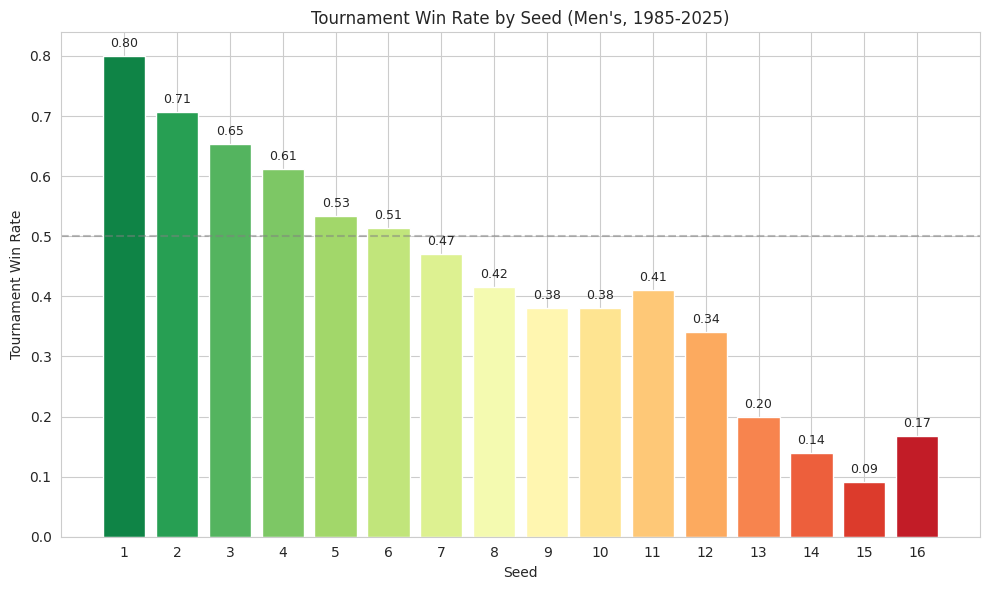

In [7]:
# Win rate by seed — how often does each seed win its tournament games?
# Build team-centric view of tourney games with seeds
w_rows = tourney_with_seeds[['Season', 'WTeamID', 'WSeed']].rename(
    columns={'WTeamID': 'TeamID', 'WSeed': 'SeedNum'})
w_rows['Win'] = 1

l_rows = tourney_with_seeds[['Season', 'LTeamID', 'LSeed']].rename(
    columns={'LTeamID': 'TeamID', 'LSeed': 'SeedNum'})
l_rows['Win'] = 0

seed_games = pd.concat([w_rows, l_rows], ignore_index=True).dropna(subset=['SeedNum'])
seed_games['SeedNum'] = seed_games['SeedNum'].astype(int)

seed_winrate = seed_games.groupby('SeedNum')['Win'].agg(['mean', 'count']).reset_index()
seed_winrate.columns = ['Seed', 'WinRate', 'Games']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(seed_winrate['Seed'], seed_winrate['WinRate'], color=sns.color_palette('RdYlGn_r', 16))
ax.set_xlabel('Seed')
ax.set_ylabel('Tournament Win Rate')
ax.set_title('Tournament Win Rate by Seed (Men\'s, 1985-2025)')
ax.set_xticks(range(1, 17))
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, (_, row) in zip(bars, seed_winrate.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row["WinRate"]:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
save_plot(fig, 'seed_win_rate')
plt.show()

In [8]:
# Seed matchup win probability matrix
# For each (higher seed vs lower seed) matchup, what fraction does the higher seed win?
matchups = tourney_with_seeds.dropna(subset=['WSeed', 'LSeed']).copy()
matchups['HighSeed'] = matchups[['WSeed', 'LSeed']].min(axis=1).astype(int)
matchups['LowSeed'] = matchups[['WSeed', 'LSeed']].max(axis=1).astype(int)
matchups['HighSeedWon'] = (matchups['WSeed'] == matchups['HighSeed']).astype(int)

matchup_matrix = matchups.groupby(['HighSeed', 'LowSeed'])['HighSeedWon'].agg(['mean', 'count']).reset_index()
matchup_matrix.columns = ['HighSeed', 'LowSeed', 'HighSeedWinRate', 'Count']

# Show common first-round matchups
first_round = matchup_matrix[matchup_matrix['HighSeed'] + matchup_matrix['LowSeed'] == 17]
first_round = first_round.sort_values('HighSeed')
print("First Round Matchup Win Rates (Higher Seed):")
for _, row in first_round.iterrows():
    print(f"  #{int(row['HighSeed'])} vs #{int(row['LowSeed'])}: "
          f"{row['HighSeedWinRate']:.3f} ({int(row['Count'])} games)")

First Round Matchup Win Rates (Higher Seed):
  #1 vs #16: 0.988 (160 games)
  #2 vs #15: 0.931 (160 games)
  #3 vs #14: 0.856 (160 games)
  #4 vs #13: 0.794 (160 games)
  #5 vs #12: 0.644 (160 games)
  #6 vs #11: 0.613 (160 games)
  #7 vs #10: 0.610 (159 games)
  #8 vs #9: 0.481 (160 games)


Saved: output/seed_matchup_heatmap.png


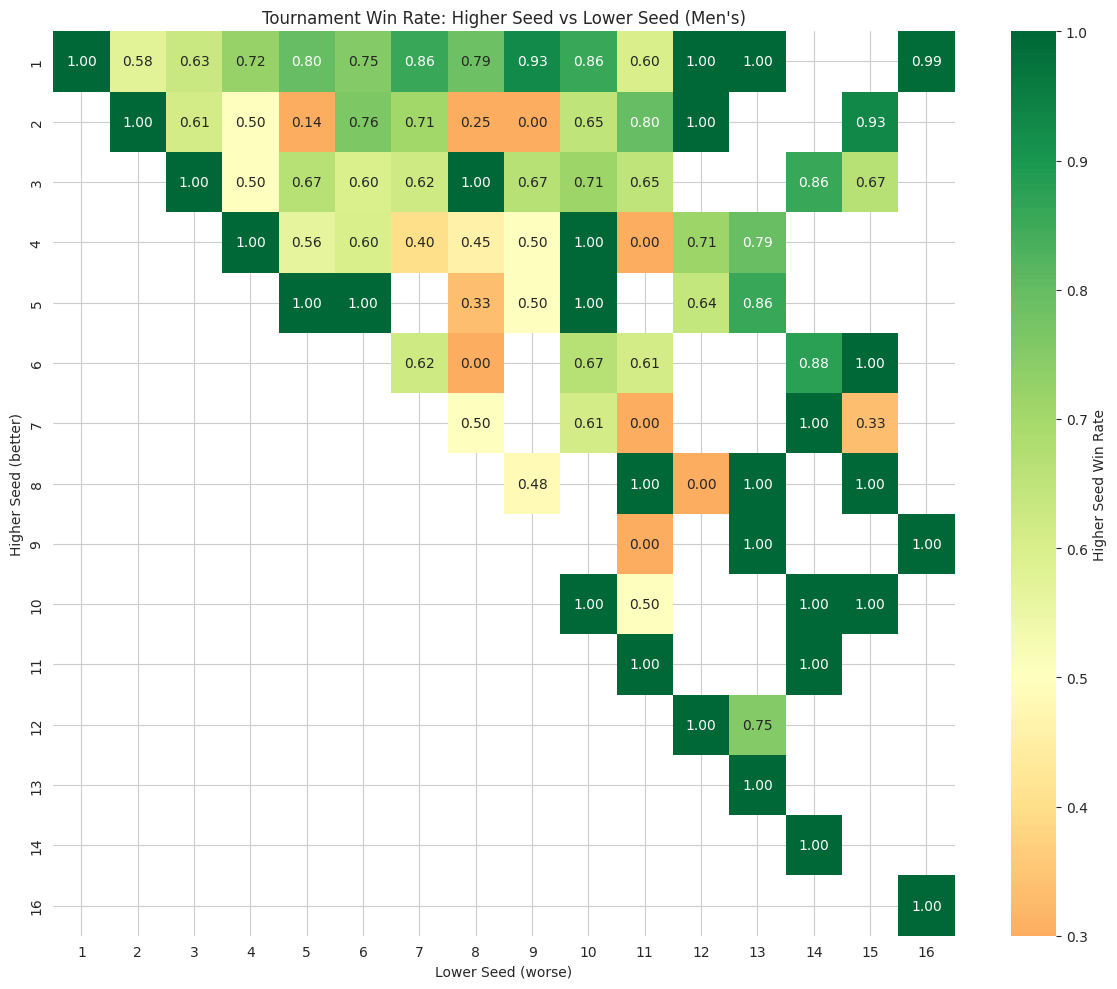

In [9]:
# Seed matchup heatmap
pivot = matchup_matrix.pivot_table(
    index='HighSeed', columns='LowSeed', values='HighSeedWinRate'
)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5,
            vmin=0.3, vmax=1.0, ax=ax, cbar_kws={'label': 'Higher Seed Win Rate'})
ax.set_title('Tournament Win Rate: Higher Seed vs Lower Seed (Men\'s)')
ax.set_xlabel('Lower Seed (worse)')
ax.set_ylabel('Higher Seed (better)')
plt.tight_layout()
save_plot(fig, 'seed_matchup_heatmap')
plt.show()

Saved: output/upset_rate_over_time.png


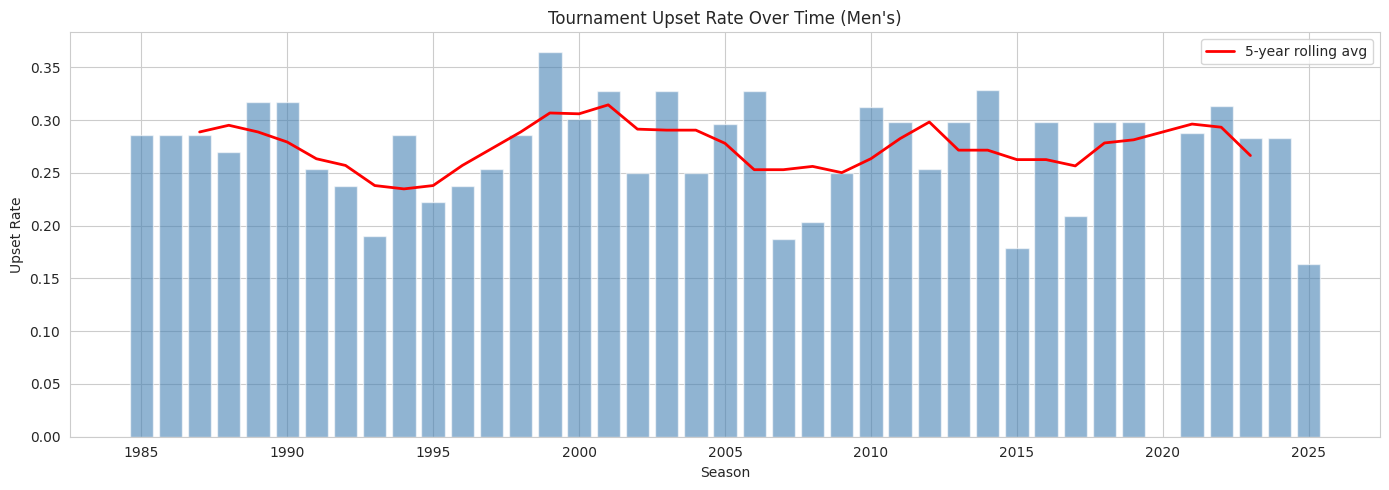

In [10]:
# Upset rate over time — is the tournament getting more or less predictable?
upset_by_year = tourney_with_seeds.groupby('Season')['Upset'].mean().reset_index()
upset_by_year.columns = ['Season', 'UpsetRate']

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(upset_by_year['Season'], upset_by_year['UpsetRate'], alpha=0.6, color='steelblue')
ax.plot(upset_by_year['Season'], upset_by_year['UpsetRate'].rolling(5, center=True).mean(),
        color='red', linewidth=2, label='5-year rolling avg')
ax.set_xlabel('Season')
ax.set_ylabel('Upset Rate')
ax.set_title('Tournament Upset Rate Over Time (Men\'s)')
ax.legend()
plt.tight_layout()
save_plot(fig, 'upset_rate_over_time')
plt.show()

## 3. Massey Ordinal System Analysis

Research indicates that the top Massey systems (POM, SAG, MOR, WLK) are among the best predictors. Let's verify which systems are most predictive of tournament outcomes.

In [11]:
# For each tournament game, compute rank difference per system.
# Then measure how well each system's rank difference predicts the winner.

# Join massey rankings to tournament games
tourney_massey = tourney_games[['Season', 'WTeamID', 'LTeamID']].copy()

# Get all system columns
system_cols = [c for c in massey.columns if c not in ['Season', 'TeamID', 'AvgOrdinalRank', 'TopSystemsAvgRank']]

# Join winner rankings
tourney_massey = tourney_massey.merge(
    massey, left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID'], how='inner'
).drop(columns=['TeamID'])
w_rename = {c: f'W_{c}' for c in system_cols + ['AvgOrdinalRank', 'TopSystemsAvgRank']}
tourney_massey = tourney_massey.rename(columns=w_rename)

# Join loser rankings
tourney_massey = tourney_massey.merge(
    massey, left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID'], how='inner'
).drop(columns=['TeamID'])
l_rename = {c: f'L_{c}' for c in system_cols + ['AvgOrdinalRank', 'TopSystemsAvgRank']}
tourney_massey = tourney_massey.rename(columns=l_rename)

print(f"Tournament games with Massey data: {len(tourney_massey)} (2003+ only)")

Tournament games with Massey data: 2585 (2003+ only)


In [12]:
# For each system, compute accuracy: what fraction of games did the better-ranked team win?
# Lower rank = better team, so winner should have lower rank.
system_accuracy = {}

for sys in system_cols:
    w_col = f'W_{sys}'
    l_col = f'L_{sys}'
    if w_col in tourney_massey.columns and l_col in tourney_massey.columns:
        valid = tourney_massey.dropna(subset=[w_col, l_col])
        if len(valid) >= 50:  # Need enough games to be meaningful
            correct = (valid[w_col] < valid[l_col]).mean()  # Winner had better (lower) rank
            system_accuracy[sys] = {'accuracy': correct, 'games': len(valid)}

# Also add composite metrics
for metric in ['AvgOrdinalRank', 'TopSystemsAvgRank']:
    valid = tourney_massey.dropna(subset=[f'W_{metric}', f'L_{metric}'])
    correct = (valid[f'W_{metric}'] < valid[f'L_{metric}']).mean()
    system_accuracy[metric] = {'accuracy': correct, 'games': len(valid)}

acc_df = pd.DataFrame(system_accuracy).T.sort_values('accuracy', ascending=False)
acc_df = acc_df.reset_index().rename(columns={'index': 'System'})

print(f"\nTop 20 most predictive systems:")
print(acc_df.head(20).to_string(index=False))
print(f"\nBottom 10 systems:")
print(acc_df.tail(10).to_string(index=False))


Top 20 most predictive systems:
System  accuracy  games
   BKM  0.781250   64.0
    DP  0.776119  134.0
   LYD  0.760417  192.0
   RSE  0.750000   64.0
   TOL  0.750000   64.0
   UCS  0.750000  192.0
   PAC  0.746269  134.0
   JCI  0.742188  128.0
   PKL  0.734375  128.0
   RIS  0.734375  128.0
   JON  0.734375   64.0
   INP  0.731343   67.0
   WLS  0.731343   67.0
   WAB  0.731343   67.0
   TSR  0.729167  384.0
   ISR  0.726562  256.0
   STR  0.726562  256.0
   KLK  0.726098  387.0
   HKB  0.725191  262.0
   ROH  0.723958  192.0

Bottom 10 systems:
System  accuracy  games
   KOS  0.631841  201.0
   DDB  0.626866   67.0
   PEQ  0.626866   67.0
   NOR  0.625000   64.0
   ROG  0.611940  134.0
   TRX  0.610390   77.0
    AP  0.608424  641.0
   USA  0.606688  628.0
   DES  0.597328  524.0
   BP5  0.597015   67.0


Saved: output/massey_system_accuracy.png


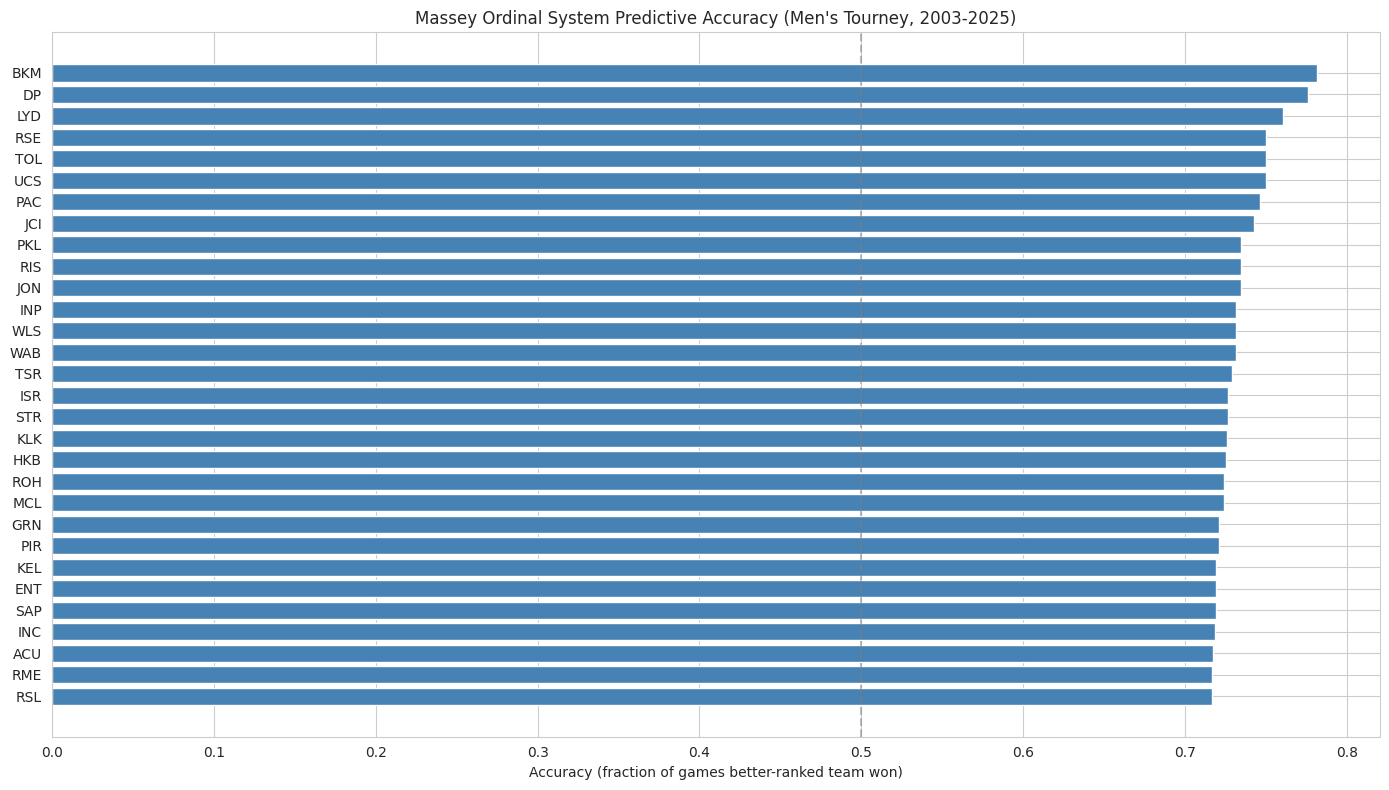

In [13]:
# Plot top 30 systems
top30 = acc_df.head(30)

fig, ax = plt.subplots(figsize=(14, 8))
colors = ['gold' if s in ['POM', 'SAG', 'MOR', 'WLK', 'TopSystemsAvgRank', 'AvgOrdinalRank'] 
          else 'steelblue' for s in top30['System']]
ax.barh(range(len(top30)), top30['accuracy'], color=colors)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['System'])
ax.set_xlabel('Accuracy (fraction of games better-ranked team won)')
ax.set_title('Massey Ordinal System Predictive Accuracy (Men\'s Tourney, 2003-2025)')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
save_plot(fig, 'massey_system_accuracy')
plt.show()

## 4. Team Stats — Tournament Teams vs Non-Tournament Teams

What regular season stats distinguish teams that make the tournament from those that don't?

In [14]:
# Mark which team-seasons made the tournament
tourney_teams = seeds[['Season', 'TeamID']].drop_duplicates()
tourney_teams['InTourney'] = 1

stats_with_tourney = team_stats.merge(tourney_teams, on=['Season', 'TeamID'], how='left')
stats_with_tourney['InTourney'] = stats_with_tourney['InTourney'].fillna(0).astype(int)

# Focus on seasons with detailed stats (2003+)
stats_detail = stats_with_tourney[stats_with_tourney.Season >= 2003].copy()

print(f"Team-seasons 2003+: {len(stats_detail)}")
print(f"Tournament teams: {stats_detail['InTourney'].sum()}")
print(f"Non-tournament teams: {(stats_detail['InTourney'] == 0).sum()}")

Team-seasons 2003+: 8346
Tournament teams: 1472
Non-tournament teams: 6874


In [15]:
# Compare key stats between tournament and non-tournament teams
compare_cols = ['WinPct', 'AvgPointDiff', 'OffEff', 'DefEff', 'NetEff',
                'FGPct', 'FG3Pct', 'FTPct', 'AvgTO', 'AvgStl', 'AvgBlk',
                'AvgOR', 'AvgDR', 'AvgAst']

comparison = stats_detail.groupby('InTourney')[compare_cols].mean().T
comparison.columns = ['Non-Tourney', 'Tourney']
comparison['Diff'] = comparison['Tourney'] - comparison['Non-Tourney']
comparison['Diff%'] = (comparison['Diff'] / comparison['Non-Tourney'] * 100).round(1)

print("Tournament vs Non-Tournament Team Averages (2003+):")
print(comparison.to_string())

Tournament vs Non-Tournament Team Averages (2003+):
              Non-Tourney    Tourney      Diff  Diff%
WinPct           0.444809   0.725778  0.280969   63.2
AvgPointDiff    -1.925341   7.817085  9.742426 -506.0
OffEff           1.006807   1.085013  0.078206    7.8
DefEff           1.034655   0.970490 -0.064165   -6.2
NetEff          -0.027848   0.114523  0.142371 -511.2
FGPct            0.432498   0.458790  0.026292    6.1
FG3Pct           0.338596   0.358421  0.019825    5.9
FTPct            0.698639   0.712255  0.013616    1.9
AvgTO           13.269980  12.398887 -0.871094   -6.6
AvgStl           6.369752   6.880798  0.511046    8.0
AvgBlk           3.281535   3.845296  0.563761   17.2
AvgOR           10.191031  10.874680  0.683650    6.7
AvgDR           23.306009  24.601998  1.295989    5.6
AvgAst          12.765198  14.437457  1.672260   13.1


Saved: output/tourney_vs_non_tourney_distributions.png


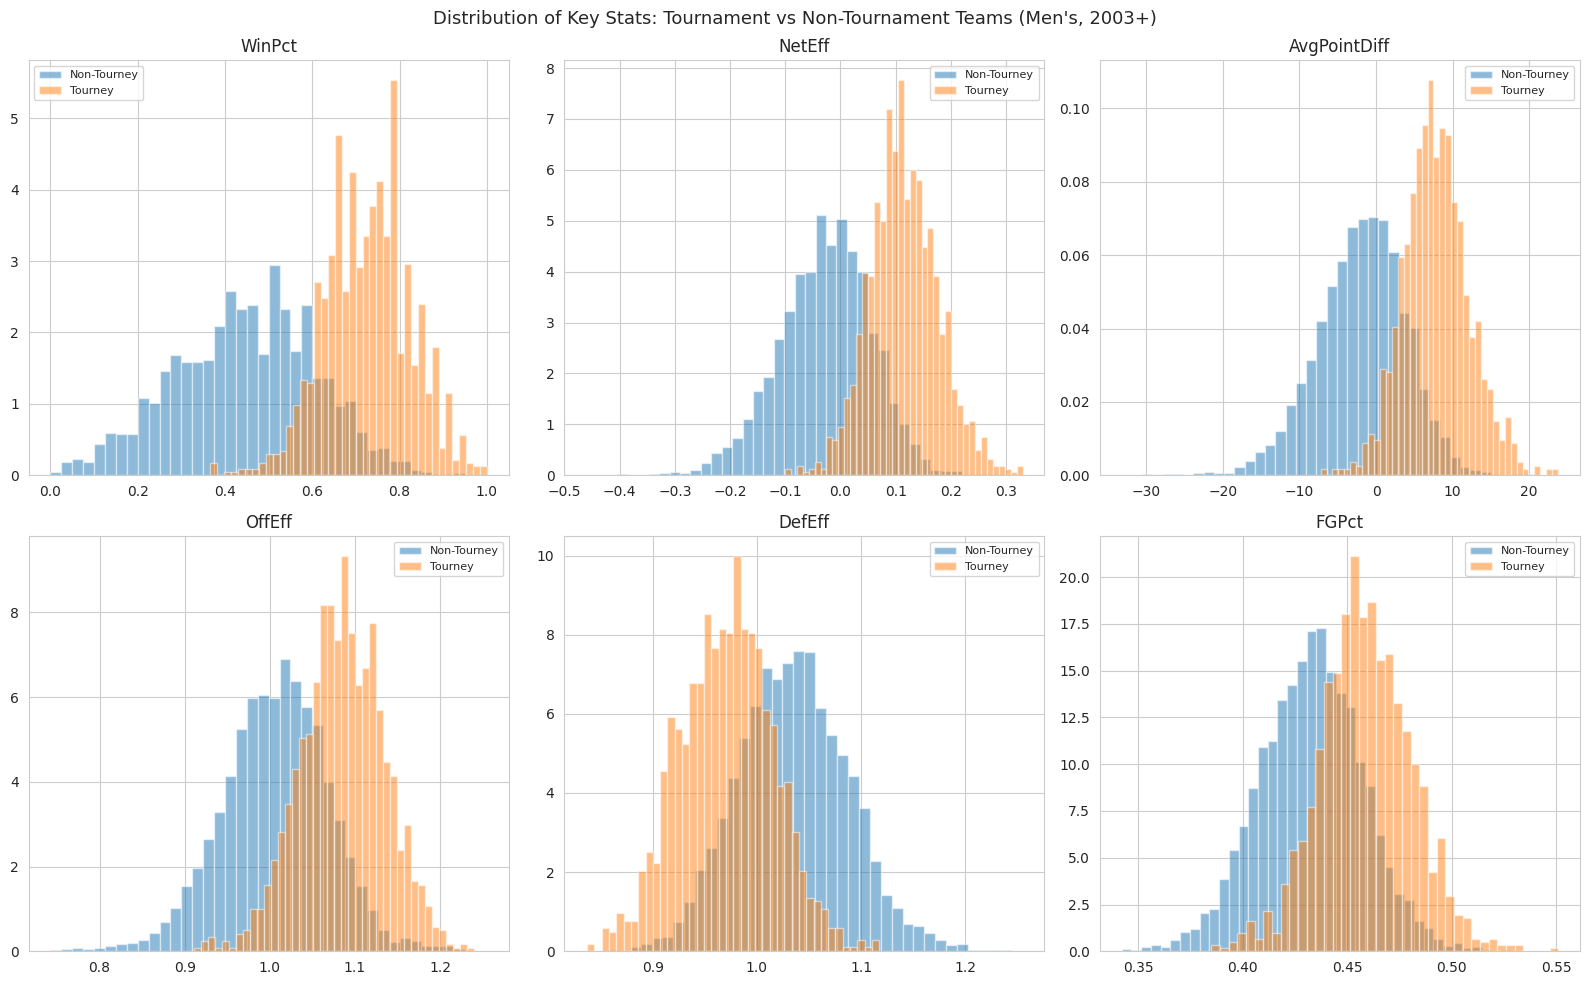

In [16]:
# Distribution plots for the most discriminating features
top_features = ['WinPct', 'NetEff', 'AvgPointDiff', 'OffEff', 'DefEff', 'FGPct']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, feat in zip(axes.flat, top_features):
    for label, group in stats_detail.groupby('InTourney'):
        name = 'Tourney' if label == 1 else 'Non-Tourney'
        ax.hist(group[feat].dropna(), bins=40, alpha=0.5, label=name, density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

fig.suptitle('Distribution of Key Stats: Tournament vs Non-Tournament Teams (Men\'s, 2003+)', fontsize=13)
plt.tight_layout()
save_plot(fig, 'tourney_vs_non_tourney_distributions')
plt.show()

## 5. Feature Correlation with Tournament Wins

Among tournament teams, which stats correlate most with winning tournament games?

Saved: output/feature_correlation_tourney_wins.png


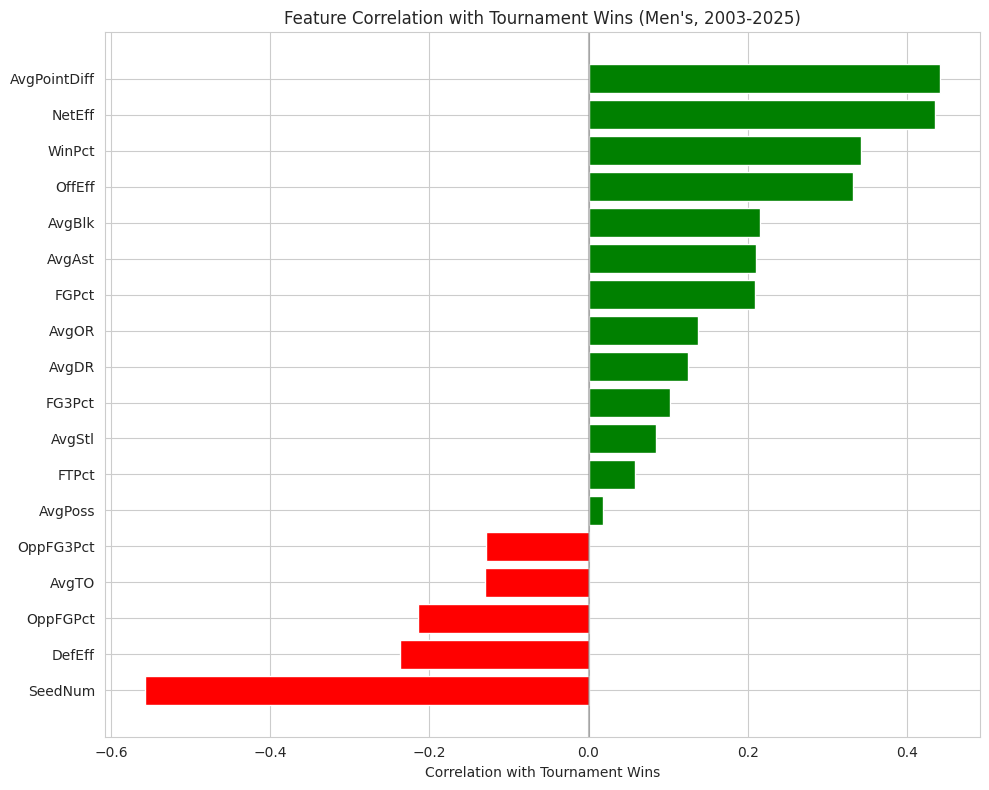


Correlation values:
  AvgPointDiff        : +0.442
  NetEff              : +0.435
  WinPct              : +0.343
  OffEff              : +0.333
  AvgBlk              : +0.216
  AvgAst              : +0.211
  FGPct               : +0.209
  AvgOR               : +0.138
  AvgDR               : +0.126
  FG3Pct              : +0.102
  AvgStl              : +0.084
  FTPct               : +0.058
  AvgPoss             : +0.018
  OppFG3Pct           : -0.129
  AvgTO               : -0.130
  OppFGPct            : -0.214
  DefEff              : -0.237
  SeedNum             : -0.558


In [17]:
# Count tournament wins per team-season
tourney_wins = tourney_games.groupby(['Season', 'WTeamID']).size().reset_index(name='TourneyWins')
tourney_wins = tourney_wins.rename(columns={'WTeamID': 'TeamID'})

# Merge with team stats (only tournament teams)
tourney_team_stats = stats_detail[stats_detail['InTourney'] == 1].merge(
    tourney_wins, on=['Season', 'TeamID'], how='left'
)
tourney_team_stats['TourneyWins'] = tourney_team_stats['TourneyWins'].fillna(0)

# Also join seeds
tourney_team_stats = tourney_team_stats.merge(
    seeds[['Season', 'TeamID', 'SeedNum']], on=['Season', 'TeamID'], how='left'
)

# Correlation with tournament wins
corr_cols = ['SeedNum', 'WinPct', 'AvgPointDiff', 'OffEff', 'DefEff', 'NetEff',
             'FGPct', 'FG3Pct', 'FTPct', 'AvgTO', 'AvgStl', 'AvgBlk',
             'AvgOR', 'AvgDR', 'AvgAst', 'AvgPoss', 'OppFGPct', 'OppFG3Pct']

correlations = tourney_team_stats[corr_cols + ['TourneyWins']].corr()['TourneyWins'].drop('TourneyWins')
correlations = correlations.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if v > 0 else 'red' for v in correlations.values]
ax.barh(range(len(correlations)), correlations.values, color=colors)
ax.set_yticks(range(len(correlations)))
ax.set_yticklabels(correlations.index)
ax.set_xlabel('Correlation with Tournament Wins')
ax.set_title('Feature Correlation with Tournament Wins (Men\'s, 2003-2025)')
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
ax.invert_yaxis()
plt.tight_layout()
save_plot(fig, 'feature_correlation_tourney_wins')
plt.show()

print("\nCorrelation values:")
for feat, corr in correlations.items():
    print(f"  {feat:20s}: {corr:+.3f}")

## 6. Scoring and Pace Trends Over Time

Saved: output/scoring_and_pace_trends.png


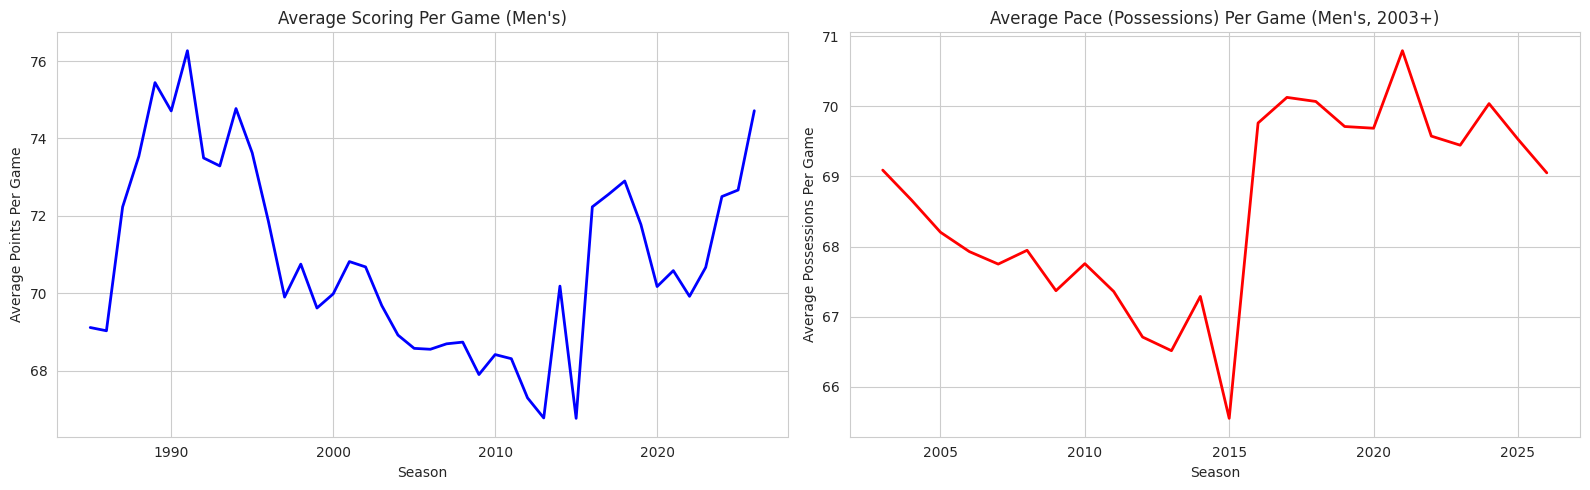

In [18]:
# Average score per season
season_avg = team_stats.groupby('Season')[['AvgScore', 'AvgOppScore', 'AvgPoss']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scoring trend
axes[0].plot(season_avg['Season'], season_avg['AvgScore'], 'b-', linewidth=2)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Average Points Per Game')
axes[0].set_title('Average Scoring Per Game (Men\'s)')

# Pace trend (possessions, 2003+ only)
pace = season_avg.dropna(subset=['AvgPoss'])
axes[1].plot(pace['Season'], pace['AvgPoss'], 'r-', linewidth=2)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Possessions Per Game')
axes[1].set_title('Average Pace (Possessions) Per Game (Men\'s, 2003+)')

plt.tight_layout()
save_plot(fig, 'scoring_and_pace_trends')
plt.show()

## 7. Seed vs Massey Rank Comparison

How well do seeds align with Massey rankings? Disagreements between the two might be a useful feature.

Saved: output/seed_vs_massey_rank.png


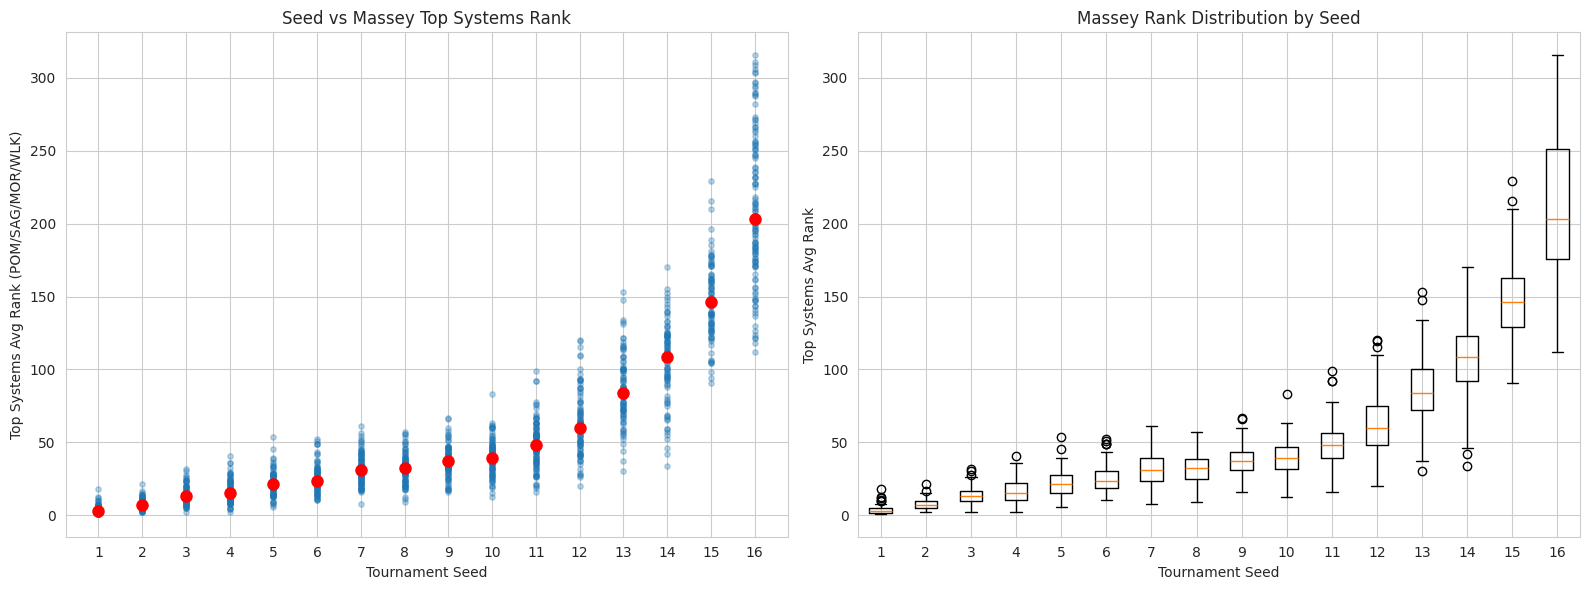

Correlation between Seed and Top Systems Rank: 0.814


In [19]:
# Join seeds with top systems average rank
seed_massey = seeds[seeds.Season >= 2003].merge(
    massey[['Season', 'TeamID', 'TopSystemsAvgRank', 'AvgOrdinalRank']],
    on=['Season', 'TeamID'],
    how='inner'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Seed vs Top Systems Rank
axes[0].scatter(seed_massey['SeedNum'], seed_massey['TopSystemsAvgRank'], alpha=0.3, s=15)
for seed in range(1, 17):
    med = seed_massey[seed_massey.SeedNum == seed]['TopSystemsAvgRank'].median()
    axes[0].plot(seed, med, 'ro', markersize=8)
axes[0].set_xlabel('Tournament Seed')
axes[0].set_ylabel('Top Systems Avg Rank (POM/SAG/MOR/WLK)')
axes[0].set_title('Seed vs Massey Top Systems Rank')
axes[0].set_xticks(range(1, 17))

# Distribution of rank by seed (box plot)
seed_massey_clean = seed_massey.dropna(subset=['TopSystemsAvgRank'])
axes[1].boxplot([seed_massey_clean[seed_massey_clean.SeedNum == s]['TopSystemsAvgRank'].values 
                 for s in range(1, 17)],
                labels=range(1, 17))
axes[1].set_xlabel('Tournament Seed')
axes[1].set_ylabel('Top Systems Avg Rank')
axes[1].set_title('Massey Rank Distribution by Seed')

plt.tight_layout()
save_plot(fig, 'seed_vs_massey_rank')
plt.show()

# Correlation
corr = seed_massey[['SeedNum', 'TopSystemsAvgRank']].corr().iloc[0, 1]
print(f"Correlation between Seed and Top Systems Rank: {corr:.3f}")

## 8. Power Conference Analysis

In [20]:
# How do power conference teams perform in the tournament?
tourney_meta = tourney_team_stats.merge(
    team_meta[['Season', 'TeamID', 'IsPowerConf', 'ConfAbbrev']],
    on=['Season', 'TeamID'],
    how='left'
)

power_perf = tourney_meta.groupby('IsPowerConf').agg(
    AvgTourneyWins=('TourneyWins', 'mean'),
    AvgSeed=('SeedNum', 'mean'),
    Count=('TeamID', 'count')
).reset_index()
power_perf['IsPowerConf'] = power_perf['IsPowerConf'].map({0: 'Mid-Major', 1: 'Power Conf'})

print("Tournament Performance by Conference Type (2003+):")
print(power_perf.to_string(index=False))

# Win rate by conference in tournament
conf_wins = tourney_meta.groupby('ConfAbbrev').agg(
    AvgTourneyWins=('TourneyWins', 'mean'),
    TeamsInTourney=('TeamID', 'count')
).reset_index()
conf_wins = conf_wins[conf_wins.TeamsInTourney >= 20].sort_values('AvgTourneyWins', ascending=False)

print(f"\nTop conferences by avg tournament wins (min 20 appearances):")
print(conf_wins.head(15).to_string(index=False))

Tournament Performance by Conference Type (2003+):
IsPowerConf  AvgTourneyWins   AvgSeed  Count
  Mid-Major        0.542105 11.569737    760
 Power Conf        1.456461  5.710674    712

Top conferences by avg tournament wins (min 20 appearances):
ConfAbbrev  AvgTourneyWins  TeamsInTourney
       acc        1.666667             126
big_twelve        1.440299             134
  big_east        1.426471             136
       sec        1.412698             126
   big_ten        1.400000             140
pac_twelve        1.320000              50
   pac_ten        1.300000              40
       wcc        1.225000              40
      cusa        1.054054              37
       aac        0.964286              28
       mvc        0.885714              35
   horizon        0.840000              25
     a_ten        0.721311              61
       caa        0.538462              26
       mwc        0.492063              63


## 9. Feature Correlation Matrix

Check for multicollinearity among candidate features. Highly correlated features may need to be pruned.

Saved: output/feature_correlation_matrix.png


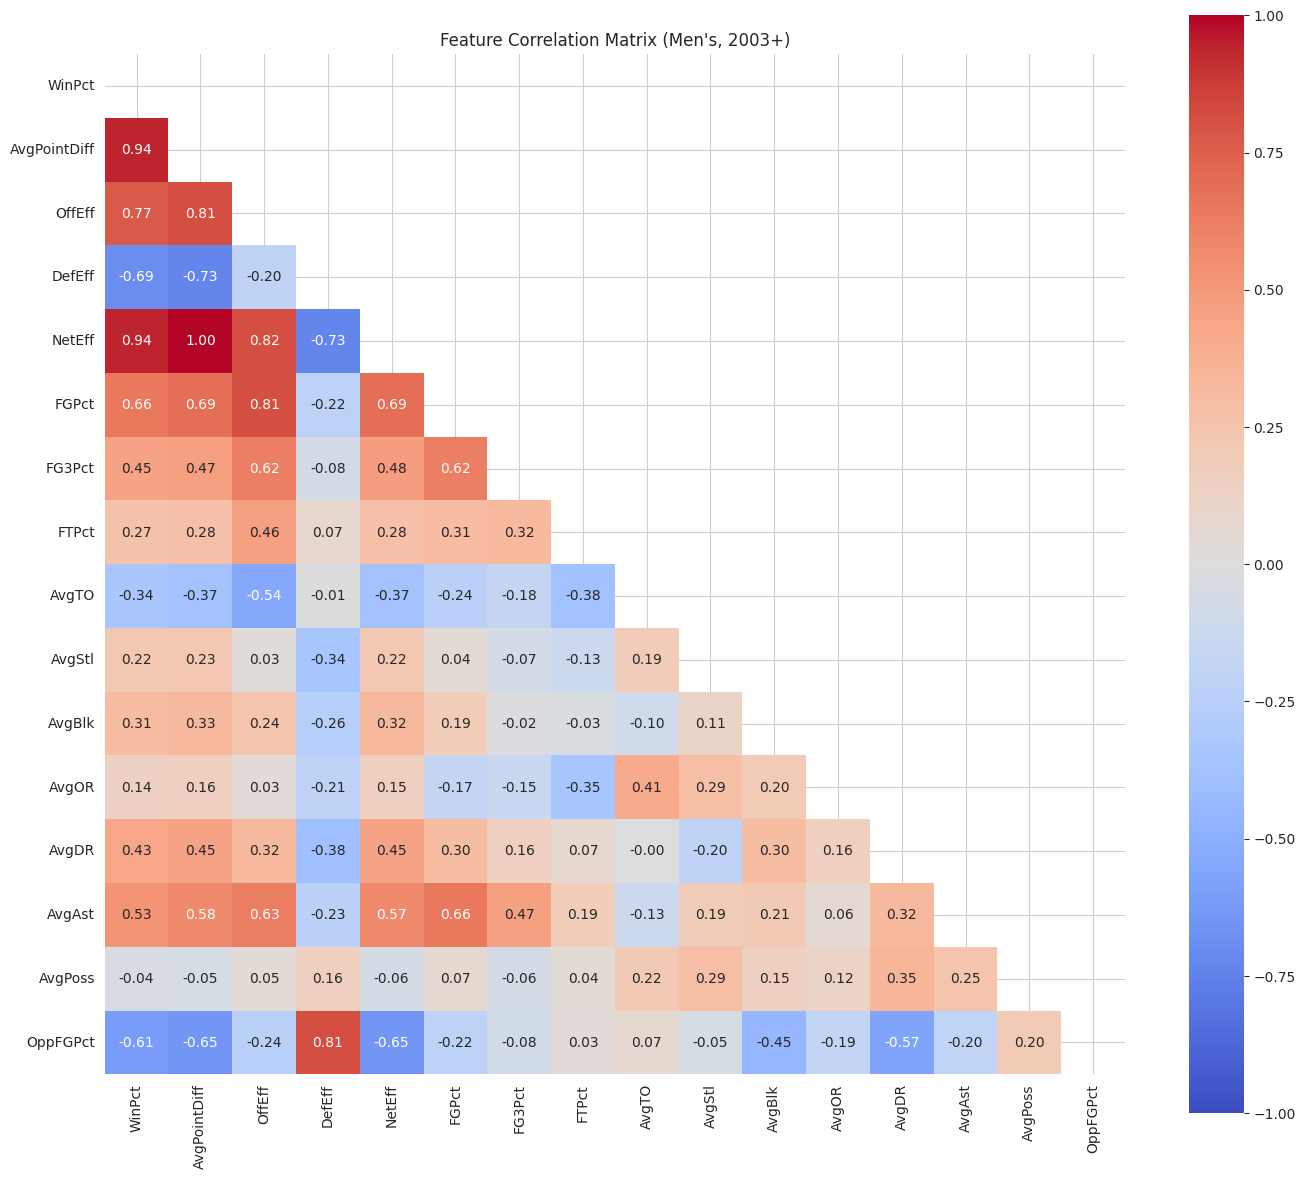


Highly correlated feature pairs (|r| > 0.7):
  WinPct <-> AvgPointDiff: 0.944
  WinPct <-> OffEff: 0.770
  WinPct <-> NetEff: 0.945
  AvgPointDiff <-> OffEff: 0.814
  AvgPointDiff <-> DefEff: -0.728
  AvgPointDiff <-> NetEff: 0.996
  OffEff <-> NetEff: 0.817
  OffEff <-> FGPct: 0.806
  DefEff <-> NetEff: -0.731
  DefEff <-> OppFGPct: 0.813


In [21]:
corr_features = ['WinPct', 'AvgPointDiff', 'OffEff', 'DefEff', 'NetEff',
                  'FGPct', 'FG3Pct', 'FTPct', 'AvgTO', 'AvgStl', 'AvgBlk',
                  'AvgOR', 'AvgDR', 'AvgAst', 'AvgPoss', 'OppFGPct']

corr_matrix = stats_detail[corr_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix (Men\'s, 2003+)')
plt.tight_layout()
save_plot(fig, 'feature_correlation_matrix')
plt.show()

# Flag highly correlated pairs
print("\nHighly correlated feature pairs (|r| > 0.7):")
for i in range(len(corr_features)):
    for j in range(i+1, len(corr_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr_features[i]} <-> {corr_features[j]}: {r:.3f}")

## 10. Key Takeaways

Summary of EDA findings to inform downstream feature engineering and modeling.

In [22]:
print("""
EDA KEY TAKEAWAYS — MEN'S
========================

1. SEEDS: Strong but imperfect predictor. 1-seeds win ~80%+ of their games.
   Upsets happen ~20-30% of the time overall. Seed difference is a must-have feature.

2. MASSEY ORDINALS: Top systems (POM, SAG, MOR, WLK) are highly predictive.
   The composite average of top systems may outperform any individual system.
   Use rank difference between teams as a feature.

3. DISCRIMINATING FEATURES: NetEff, WinPct, AvgPointDiff are the strongest
   separators between tournament and non-tournament teams. DefEff matters
   (lower is better — tournament teams play better defense).

4. TOURNAMENT WIN CORRELATES: SeedNum (negative — lower seed = more wins),
   NetEff, WinPct, and AvgPointDiff correlate most with tournament wins.
   Defensive stats (OppFGPct, DefEff) are important.

5. MULTICOLLINEARITY: WinPct, AvgPointDiff, and NetEff are highly correlated.
   OffEff and FGPct are correlated. May need to select a subset or use
   difference features to reduce redundancy.

6. TRENDS: Scoring and pace have shifted over time. Models should account for
   era effects or use relative (within-season) features rather than raw values.

7. POWER CONFERENCES: Power conference teams get better seeds and win more
   tournament games on average, but this is largely captured by seed and
   rating systems. IsPowerConf may add marginal value.

RECOMMENDED FEATURE PRIORITY:
  1. Massey top systems rank difference (POM, SAG, MOR, WLK avg)
  2. Seed difference
  3. NetEff difference (offensive - defensive efficiency)
  4. WinPct difference
  5. Defensive efficiency difference
  6. Shooting efficiency differences (FGPct, FG3Pct)
  7. Turnover and rebounding differences
""")


EDA KEY TAKEAWAYS — MEN'S

1. SEEDS: Strong but imperfect predictor. 1-seeds win ~80%+ of their games.
   Upsets happen ~20-30% of the time overall. Seed difference is a must-have feature.

2. MASSEY ORDINALS: Top systems (POM, SAG, MOR, WLK) are highly predictive.
   The composite average of top systems may outperform any individual system.
   Use rank difference between teams as a feature.

3. DISCRIMINATING FEATURES: NetEff, WinPct, AvgPointDiff are the strongest
   separators between tournament and non-tournament teams. DefEff matters
   (lower is better — tournament teams play better defense).

4. TOURNAMENT WIN CORRELATES: SeedNum (negative — lower seed = more wins),
   NetEff, WinPct, and AvgPointDiff correlate most with tournament wins.
   Defensive stats (OppFGPct, DefEff) are important.

5. MULTICOLLINEARITY: WinPct, AvgPointDiff, and NetEff are highly correlated.
   OffEff and FGPct are correlated. May need to select a subset or use
   difference features to reduce redundan